In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, RocCurveDisplay)

# 0 : Lecture des données

In [44]:
# Chargement des données
cardio = pd.read_csv("cardio_train.csv", sep=';')

# Suppression de la colonne identifiant
cardio = cardio.drop(columns=['id'])

# Aperçu des données
print(cardio.head())
print()

# Dimensions de la base
print(cardio.shape)
print()

# Informations générales
print(cardio.info())

     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393       2     168    62.0    110     80            1     1      0   
1  20228       1     156    85.0    140     90            3     1      0   
2  18857       1     165    64.0    130     70            3     1      0   
3  17623       2     169    82.0    150    100            1     1      0   
4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  

(70000, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi  

# I : Analyse exploratoire des données

In [45]:
# Test valeurs manquantes
cardio.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0
alco,0


Pas de valeurs manquantes, les données sont directement exploitables.

In [46]:
cardio.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


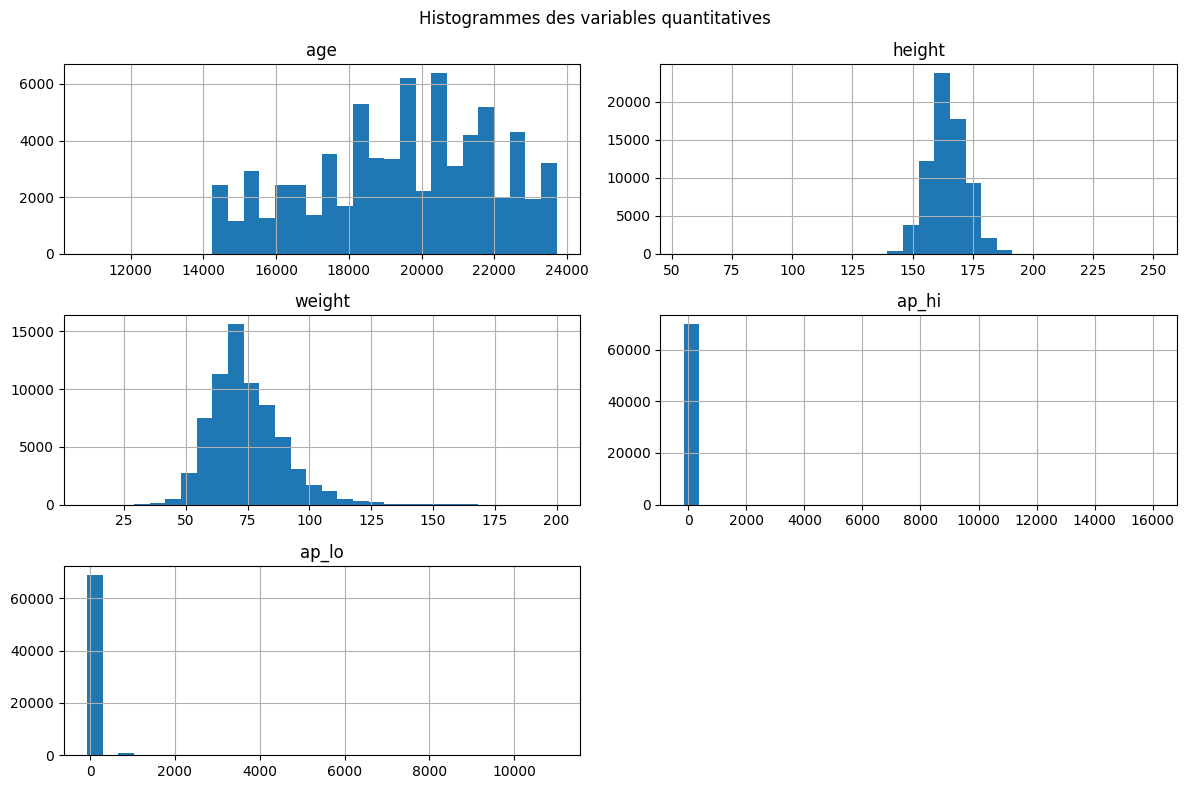

In [47]:
# Histogrammes des variables quantitatives
quant_vars = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
cardio[quant_vars].hist(bins=30, figsize=(12, 8))
plt.suptitle('Histogrammes des variables quantitatives')
plt.tight_layout()
plt.show()

Les deux classes sont relativement équilibrées, même si le nombre de sujets ayant subi un accident cardio-vasculaire est plus élevé.

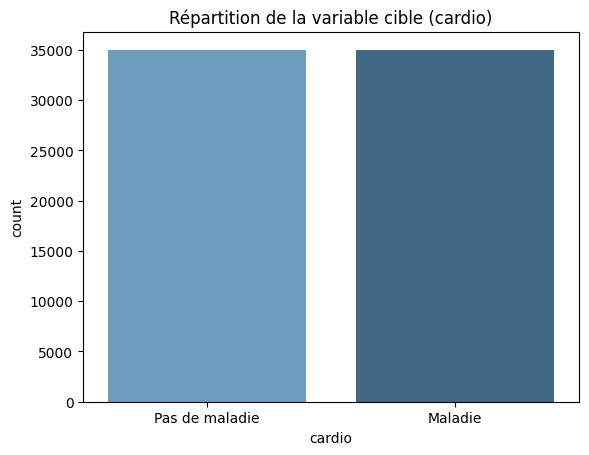

In [48]:
# Répartition de la variable cible
sns.countplot(x='cardio', data=cardio, hue='cardio', palette='Blues_d', legend=False)
plt.title('Répartition de la variable cible (cardio)')
plt.xticks([0, 1], ['Pas de maladie', 'Maladie'])
plt.show()

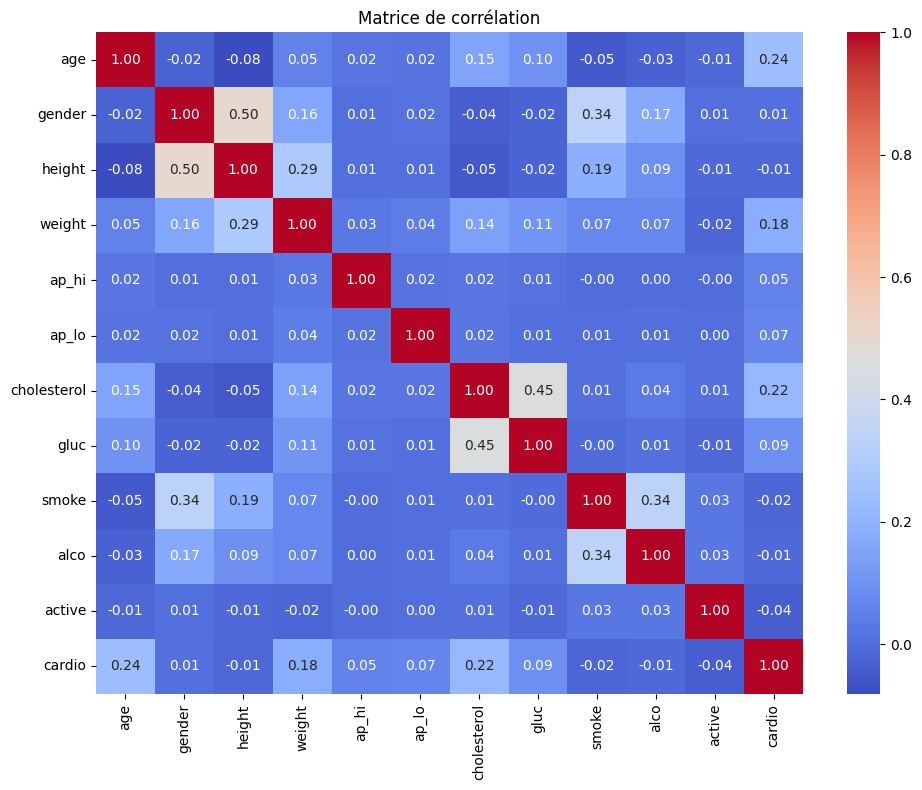

In [49]:
# Analyse des corrélations
plt.figure(figsize=(10,8))
sns.heatmap(cardio.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

Variables corrélées au risque cardiovasculaire : ap_hi, ap_lo, cholesterol, age, weight.

Variables peu corrélées au risque cardiovasculaire : smoke, alco, active, gender.

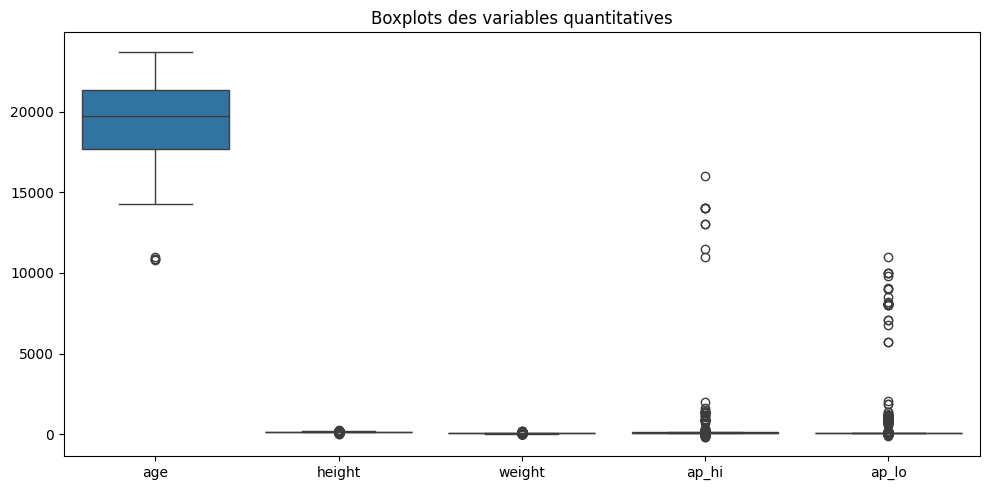

In [50]:
# Distribution des variables quantitatives sous forme de boxplots
plt.figure(figsize=(10, 5))
sns.boxplot(data=cardio[['age', 'height', 'weight', 'ap_hi', 'ap_lo']])
plt.title('Boxplots des variables quantitatives')
plt.tight_layout()
plt.show()

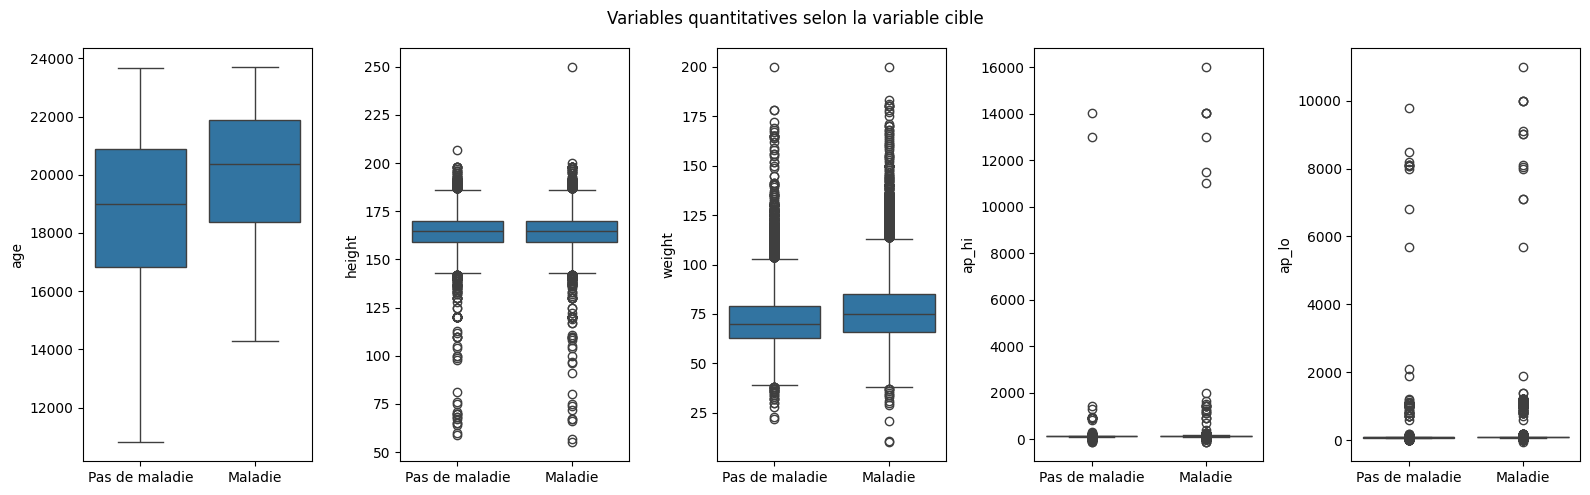

In [51]:
# Boxplots par rapport à la variable cible pour les variables quantitatives
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
for ax, var in zip(axes, ['age', 'height', 'weight', 'ap_hi', 'ap_lo']):
    sns.boxplot(x='cardio', y=var, data=cardio, ax=ax)
    ax.set_xlabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pas de maladie', 'Maladie'])
plt.suptitle('Variables quantitatives selon la variable cible')
plt.tight_layout()
plt.show()

# II : Prétraitement des données

In [52]:
# Suppression des observations aberrantes sur la pression artérielle
# (valeurs physiologiquement impossibles)
cardio = cardio[(cardio['ap_hi'] >= 60) & (cardio['ap_hi'] <= 250)]
cardio = cardio[(cardio['ap_lo'] >= 40) & (cardio['ap_lo'] <= 180)]
cardio = cardio[cardio['ap_hi'] >= cardio['ap_lo']]

print("Taille après nettoyage :", cardio.shape)

Taille après nettoyage : (68673, 12)


### Séparation des données : 80% échantillon apprentissage; 20% échantillon test

Les données sont séparées en deux sous-ensembles. Un ensemble d'apprentissage regroupant 80% des données, et un ensemble de test avec les 20% des données restantes, le tout réparti aléatoirement.

In [53]:
X = cardio.drop('cardio', axis=1)
y = cardio['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Taille ensemble d'apprentissage :", X_train.shape)
print("Taille ensemble de test         :", X_test.shape)

Taille ensemble d'apprentissage : (54938, 11)
Taille ensemble de test         : (13735, 11)


La variable stratify = y signifie qu'on préserve la proportion des deux classes target dans chaque sous-ensemble.

### Standardisation des variables

On a vu grâce aux histogrammes que les variables quantitatives possèdent des amplitudes très différentes. C'est le cas par exemple entre la variable age (en jours) et la variable weight (en kg). C'est pourquoi une standardisation des données qui consiste à centrer et réduire les variables quantitatives (moyenne = 0; écart type = 1), est nécessaire pour éviter qu'une variable domine les autres dans le calcul des distances ou dans l'optimisation des modèles que nous utiliserons plus tard (KNN, Ridge, Lasso).

In [54]:
# Standardisation des variables quantitatives.
quantitative_vars = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()
X_train[quantitative_vars] = scaler.fit_transform(X_train[quantitative_vars])
X_test[quantitative_vars] = scaler.transform(X_test[quantitative_vars])

In [55]:
# Passage pandas --> numpy
X_app = X_train.to_numpy()
X_test_np = X_test.to_numpy()

y_app = y_train.to_numpy()
y_test_np = y_test.to_numpy()

feature_names = list(X_train.columns)

# Sous-ensemble pour la validation croisée (les méthodes Ridge/Lasso/KNN
# n'ont pas besoin de tout le jeu pour choisir les hyperparamètres)
np.random.seed(42)
idx_cv = np.random.choice(len(y_app), size=10000, replace=False)
X_cv = X_app[idx_cv]
y_cv = y_app[idx_cv]

# III : Modélisation

## Ridge

On code la régression logistique Ridge à l'aide de la bibliothèque sklearn, avec le paramètre penalty='l2'. Le paramètre de régularisation est choisi par validation croisée Monte Carlo sur l'ensemble d'apprentissage.


--- Ridge logistique ---
Accuracy Ridge CV (alpha=0.001) = 0.73125
Accuracy Ridge CV (alpha=0.01) = 0.73125
Accuracy Ridge CV (alpha=0.1) = 0.73125
Accuracy Ridge CV (alpha=1) = 0.73135
Accuracy Ridge CV (alpha=10) = 0.73155
Accuracy Ridge CV (alpha=50) = 0.732

Meilleur alpha Ridge : 50
Accuracy Ridge Test final = 0.728066982162359


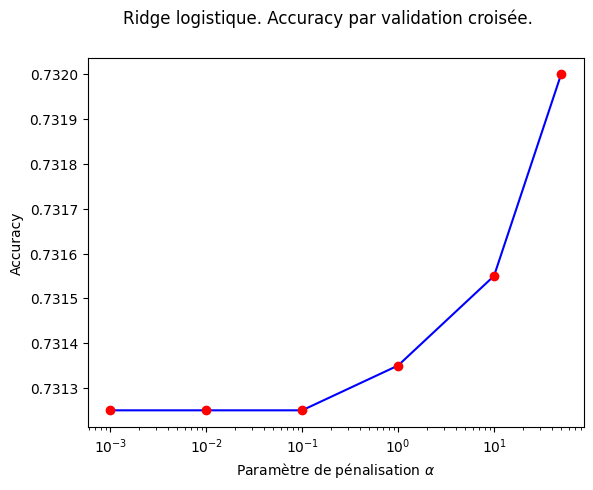

In [56]:
#---------------------------------------------------------------------------------------------
# RIDGE LOGISTIQUE AVEC INDICATEUR accuracy
#---------------------------------------------------------------------------------------------

print("\n--- Ridge logistique ---")

B = 10
ntest_cv = len(y_cv) // 5
alphas_ridge = [0.001, 0.01, 0.1, 1, 10, 50]
acc_ridge = np.zeros(len(alphas_ridge))

for b in range(B):

    per = np.random.permutation(len(y_cv))

    lt = per[:ntest_cv]
    la = per[ntest_cv:]

    Xa = X_cv[la, :]
    ya = y_cv[la]

    Xt = X_cv[lt, :]
    yt = y_cv[lt]

    for j, a in enumerate(alphas_ridge):

        mod_ridge = LogisticRegression(penalty='l2', C=1/a, solver='lbfgs', max_iter=500)
        mod_ridge.fit(Xa, ya)
        yh = mod_ridge.predict(Xt)
        acc_ridge[j] += accuracy_score(yt, yh)

acc_ridge = acc_ridge / B

for j, a in enumerate(alphas_ridge):
    print(f"Accuracy Ridge CV (alpha={a}) = {acc_ridge[j].round(6)}")

best_alpha_ridge = alphas_ridge[np.argmax(acc_ridge)]
print(f"\nMeilleur alpha Ridge : {best_alpha_ridge}")

mod_ridge_final = LogisticRegression(penalty='l2', C=1/best_alpha_ridge, solver='lbfgs', max_iter=500)
mod_ridge_final.fit(X_app, y_app)
yhat_ridge_test = mod_ridge_final.predict(X_test_np)

print('Accuracy Ridge Test final =', accuracy_score(y_test_np, yhat_ridge_test))

plt.figure()
plt.suptitle(r'Ridge logistique. Accuracy par validation croisée.')
plt.semilogx()
plt.plot(alphas_ridge, acc_ridge, 'b-')
plt.plot(alphas_ridge, acc_ridge, 'ro')
plt.xlabel(r'Paramètre de pénalisation $\alpha$')
plt.ylabel('Accuracy')
plt.show()

In [57]:
# Coefficients Ridge
print("Coefficients Ridge :")
for name, coef in zip(feature_names, mod_ridge_final.coef_[0]):
    print(f"  {name:20s} : {coef:.4f}")

Coefficients Ridge :
  age                  : 0.3408
  gender               : -0.0453
  height               : -0.0293
  weight               : 0.1598
  ap_hi                : 0.9378
  ap_lo                : 0.0959
  cholesterol          : 0.4957
  gluc                 : -0.1258
  smoke                : -0.1184
  alco                 : -0.2027
  active               : -0.2104


## LASSO


--- Lasso ---
Accuracy Lasso CV (alpha=0.001) = 0.72635
Accuracy Lasso CV (alpha=0.01) = 0.7263
Accuracy Lasso CV (alpha=0.1) = 0.7263
Accuracy Lasso CV (alpha=1) = 0.72635
Accuracy Lasso CV (alpha=10) = 0.72625
Accuracy Lasso CV (alpha=100) = 0.71705

Meilleur alpha Lasso : 0.001
Accuracy Lasso Test final = 0.7282854022570077


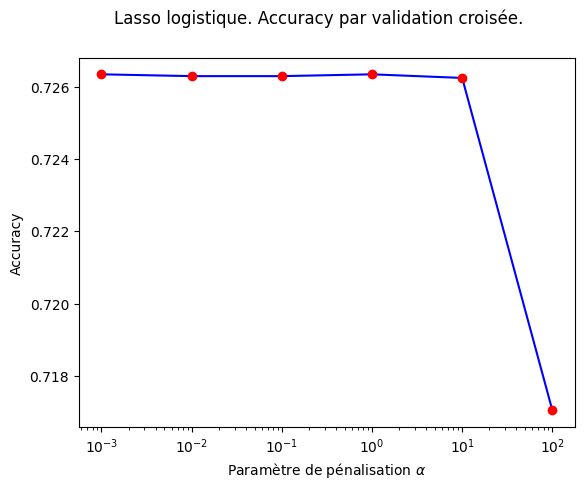

In [58]:
#---------------------------------------------------------------------------------------------
# LASSO LOGISTIQUE AVEC INDICATEUR accuracy
#---------------------------------------------------------------------------------------------

print("\n--- Lasso ---")

B = 10
ntest_cv = len(y_cv) // 5
alphas_lasso = [0.001, 0.01, 0.1, 1, 10, 100]
acc_lasso = np.zeros(len(alphas_lasso))

for b in range(B):

    per = np.random.permutation(len(y_cv))

    lt = per[:ntest_cv]
    la = per[ntest_cv:]

    Xa = X_cv[la, :]
    ya = y_cv[la]

    Xt = X_cv[lt, :]
    yt = y_cv[lt]

    for j, a in enumerate(alphas_lasso):

        mod_lasso = LogisticRegression(penalty='l1', C=1/a, solver='liblinear', max_iter=500)
        mod_lasso.fit(Xa, ya)
        yh = mod_lasso.predict(Xt)
        acc_lasso[j] += accuracy_score(yt, yh)

acc_lasso = acc_lasso / B

for j, a in enumerate(alphas_lasso):
    print(f"Accuracy Lasso CV (alpha={a}) = {acc_lasso[j].round(6)}")

best_alpha_lasso = alphas_lasso[np.argmax(acc_lasso)]
print(f"\nMeilleur alpha Lasso : {best_alpha_lasso}")

mod_lasso_final = LogisticRegression(penalty='l1', C=1/best_alpha_lasso, solver='liblinear', max_iter=500)
mod_lasso_final.fit(X_app, y_app)
yhat_lasso_test = mod_lasso_final.predict(X_test_np)

print('Accuracy Lasso Test final =', accuracy_score(y_test_np, yhat_lasso_test))

plt.figure()
plt.suptitle(r'Lasso logistique. Accuracy par validation croisée.')
plt.semilogx()
plt.plot(alphas_lasso, acc_lasso, 'b-')
plt.plot(alphas_lasso, acc_lasso, 'ro')
plt.xlabel(r'Paramètre de pénalisation $\alpha$')
plt.ylabel('Accuracy')
plt.show()

In [59]:
# Coefficients Lasso : sélection de variables
coef_lasso = mod_lasso_final.coef_[0]
print("Coefficients Lasso (variables avec coeff != 0) :")
for name, coef in zip(feature_names, coef_lasso):
    if coef != 0:
        print(f"  {name:20s} : {coef:.4f}")
print(f"\nNombre de variables avec coeff non nul : {np.sum(coef_lasso != 0)} / {len(coef_lasso)}")
print("(Un alpha faible implique une pénalisation faible : peu de variables sont annulées)")

Coefficients Lasso (variables avec coeff != 0) :
  age                  : 0.3419
  gender               : -0.0431
  height               : -0.0291
  weight               : 0.1598
  ap_hi                : 0.9494
  ap_lo                : 0.0897
  cholesterol          : 0.5058
  gluc                 : -0.1336
  smoke                : -0.1208
  alco                 : -0.2184
  active               : -0.2185

Nombre de variables avec coeff non nul : 11 / 11
(Un alpha faible implique une pénalisation faible : peu de variables sont annulées)


## KNN


--- KNN ---
Accuracy KNN CV (K=1) = 0.63475
Accuracy KNN CV (K=3) = 0.6724
Accuracy KNN CV (K=5) = 0.6933
Accuracy KNN CV (K=11) = 0.7132
Accuracy KNN CV (K=21) = 0.7262
Accuracy KNN CV (K=41) = 0.7331
Accuracy KNN CV (K=61) = 0.73245
Accuracy KNN CV (K=101) = 0.7316

Meilleur K : 41
Accuracy KNN Test final = 0.7333818711321441


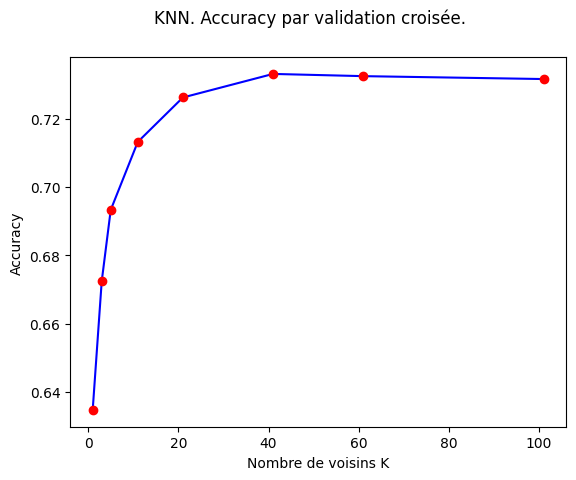

In [60]:
#---------------------------------------------------------------------------------------------
# K PLUS PROCHES VOISINS (KNN)
#---------------------------------------------------------------------------------------------

print("\n--- KNN ---")

B = 10
ntest_cv = len(y_cv) // 5
K_values = [1, 3, 5, 11, 21, 41, 61, 101]
acc_knn = np.zeros(len(K_values))

for b in range(B):

    per = np.random.permutation(len(y_cv))

    lt = per[:ntest_cv]
    la = per[ntest_cv:]

    Xa = X_cv[la, :]
    ya = y_cv[la]

    Xt = X_cv[lt, :]
    yt = y_cv[lt]

    for j, k in enumerate(K_values):

        mod_knn = KNeighborsClassifier(n_neighbors=k)
        mod_knn.fit(Xa, ya)
        yh = mod_knn.predict(Xt)
        acc_knn[j] += accuracy_score(yt, yh)

acc_knn = acc_knn / B

for j, k in enumerate(K_values):
    print(f"Accuracy KNN CV (K={k}) = {acc_knn[j].round(6)}")

best_k = K_values[np.argmax(acc_knn)]
print(f"\nMeilleur K : {best_k}")

mod_knn_final = KNeighborsClassifier(n_neighbors=best_k)
mod_knn_final.fit(X_app, y_app)
yhat_knn_test = mod_knn_final.predict(X_test_np)
print('Accuracy KNN Test final =', accuracy_score(y_test_np, yhat_knn_test))

plt.figure()
plt.suptitle(r'KNN. Accuracy par validation croisée.')
plt.plot(K_values, acc_knn, 'b-')
plt.plot(K_values, acc_knn, 'ro')
plt.xlabel(r'Nombre de voisins K')
plt.ylabel('Accuracy')
plt.show()

KNN fonctionne nettement moins bien que les méthodes logistiques. La méthode KNN repose uniquement sur les distances euclidiennes entre un nombre k d'individus, il est efficace pour capturer des relations non linéaires entre variables et cible. L'accuracy augmente pour k grand, ce qui implique un grand biais et donc un sous-apprentissage (contrairement au cas d'un k faible).

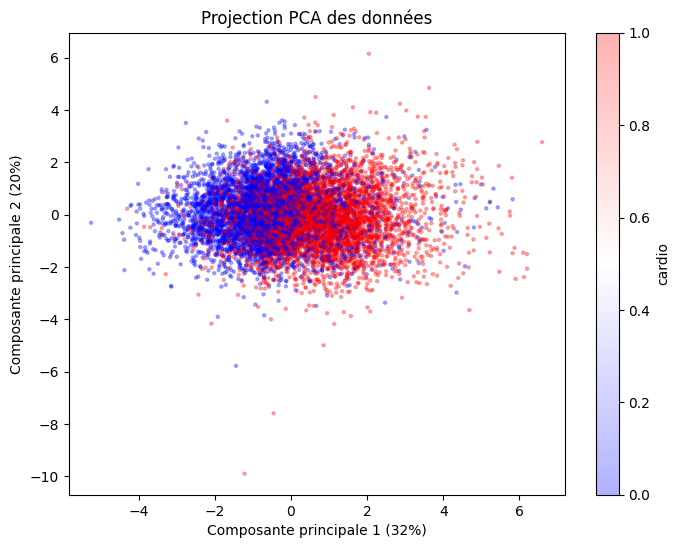

In [61]:
# Visualisation de la séparation des individus en deux classes par ACP
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cv)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_cv, alpha=0.3, s=5, cmap='bwr')
plt.xlabel('Composante principale 1 (' + str(round(pca.explained_variance_ratio_[0]*100)) + '%)')
plt.ylabel('Composante principale 2 (' + str(round(pca.explained_variance_ratio_[1]*100)) + '%)')
plt.title('Projection PCA des données')
plt.colorbar(scatter, label='cardio')
plt.show()

Si on réalise une ACP sur nos données, on voit que les individus sont partiellement séparés en deux groupes. La frontière entre les deux groupes favorise les méthodes logistiques Ridge et LASSO.

---
## Forêt aléatoire

In [62]:
B = 5
cv = ShuffleSplit(n_splits=B, test_size=0.3, random_state=0)
scoring = ("accuracy", "precision", "recall", "f1", "roc_auc")

param_grid = {'n_estimators': [50],
              'max_depth': [5, 10],
              'max_features': [3, 5]}

rf = RandomForestClassifier(random_state=42)
search = GridSearchCV(rf,
                      param_grid,
                      scoring="f1",
                      cv=cv,
                      n_jobs=-1)
search.fit(X_cv, y_cv)
print('Meilleur modèle')
print(search.best_estimator_)

Meilleur modèle
RandomForestClassifier(max_depth=10, max_features=3, n_estimators=50,
                       random_state=42)


In [63]:
rf_best = search.best_estimator_

# Validation croisée avec les hyperparamètres sélectionnés (avant le fit final)
cv_scores = cross_validate(rf_best, X_cv, y_cv, cv=cv, scoring=scoring)

# Entraînement final sur tout l'ensemble d'apprentissage avec plus d'arbres
rf_best.set_params(n_estimators=100)
rf_best.fit(X_app, y_app)

print("Performances de la forêt aléatoire")
print("Accuracy  : ", np.round(np.mean(cv_scores["test_accuracy"]),2), "(", np.round(np.std(cv_scores["test_accuracy"]),2), ")")
print("Precision : ", np.round(np.mean(cv_scores["test_precision"]),2), "(", np.round(np.std(cv_scores["test_precision"]),2), ")")
print("Recall    : ", np.round(np.mean(cv_scores["test_recall"]),2), "(", np.round(np.std(cv_scores["test_recall"]),2), ")")
print("F1-score  : ", np.round(np.mean(cv_scores["test_f1"]),2), "(", np.round(np.std(cv_scores["test_f1"]),2), ")")
print("AUC       : ", np.round(np.mean(cv_scores["test_roc_auc"]),2), "(", np.round(np.std(cv_scores["test_roc_auc"]),2), ")")

Performances de la forêt aléatoire
Accuracy  :  0.73 ( 0.01 )
Precision :  0.75 ( 0.01 )
Recall    :  0.68 ( 0.01 )
F1-score  :  0.71 ( 0.01 )
AUC       :  0.8 ( 0.0 )


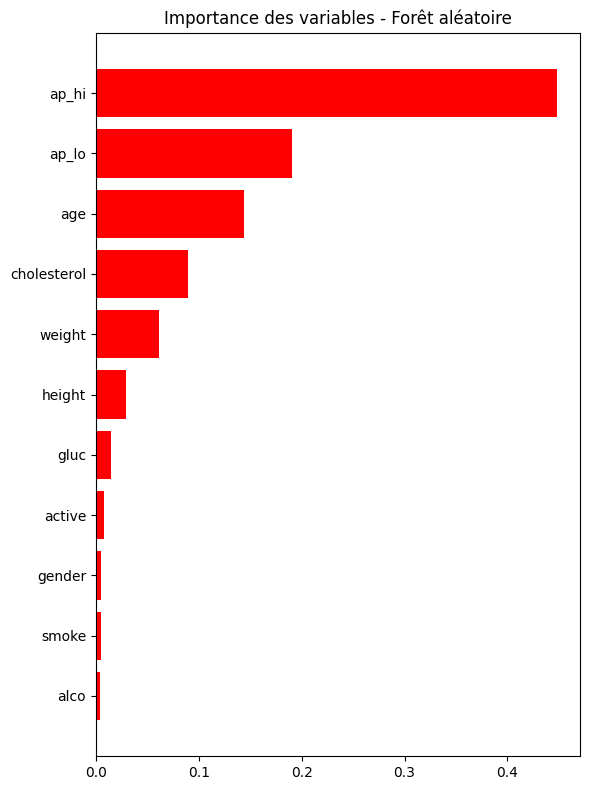

In [64]:
# Importance des variables
importances = rf_best.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(6,8))
plt.title("Importance des variables - Forêt aléatoire")
plt.barh(range(len(indices)), importances[indices], color="r", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.ylim([-1, len(indices)])
plt.tight_layout()
plt.show()

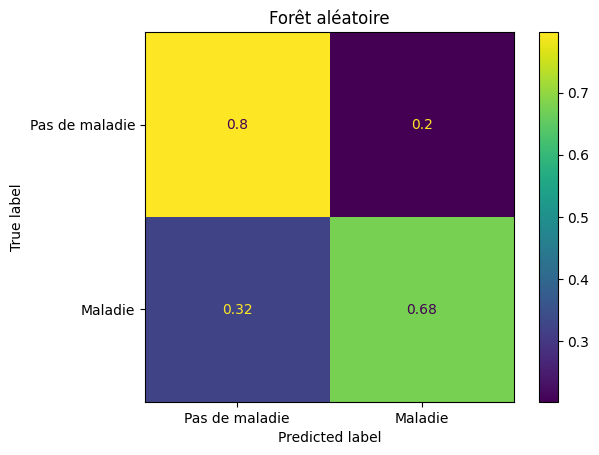

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


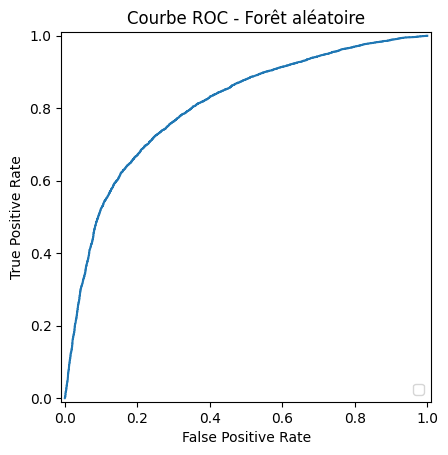

In [65]:
y_pred_rf = rf_best.predict(X_test_np)
cm_rf = confusion_matrix(y_test_np, y_pred_rf, normalize='true')
ConfusionMatrixDisplay(cm_rf, display_labels=["Pas de maladie", "Maladie"]).plot()
plt.title("Forêt aléatoire")
plt.show()

y_proba_rf = rf_best.predict_proba(X_test_np)
rf_fpr, rf_tpr, _ = roc_curve(y_test_np, y_proba_rf[:,1])
RocCurveDisplay(fpr=rf_fpr, tpr=rf_tpr).plot()
plt.title("Courbe ROC - Forêt aléatoire")
plt.show()

---
## Réseau de neurones artificiel

On construit un perceptron multicouche (MLP) avec deux couches cachées de 64 et 32 neurones, utilisant la fonction d'activation ReLU.

In [66]:
# MLP principal — early_stopping évite les iterations inutiles et le surapprentissage
mlp = MLPClassifier(hidden_layer_sizes=(64, 32),
                    activation='relu',
                    learning_rate_init=0.001,
                    max_iter=500,
                    early_stopping=True,
                    validation_fraction=0.1,
                    n_iter_no_change=10,
                    random_state=42)

cv_scores_mlp = cross_validate(mlp, X_cv, y_cv, cv=cv, scoring=scoring)

print("Performances du réseau de neurones (MLP)")
print("Architecture : couches cachées (64, 32), activation relu")
print("Accuracy  : ", np.round(np.mean(cv_scores_mlp["test_accuracy"]),2), "(", np.round(np.std(cv_scores_mlp["test_accuracy"]),2), ")")
print("Precision : ", np.round(np.mean(cv_scores_mlp["test_precision"]),2), "(", np.round(np.std(cv_scores_mlp["test_precision"]),2), ")")
print("Recall    : ", np.round(np.mean(cv_scores_mlp["test_recall"]),2), "(", np.round(np.std(cv_scores_mlp["test_recall"]),2), ")")
print("F1-score  : ", np.round(np.mean(cv_scores_mlp["test_f1"]),2), "(", np.round(np.std(cv_scores_mlp["test_f1"]),2), ")")
print("AUC       : ", np.round(np.mean(cv_scores_mlp["test_roc_auc"]),2), "(", np.round(np.std(cv_scores_mlp["test_roc_auc"]),2), ")")

Performances du réseau de neurones (MLP)
Architecture : couches cachées (64, 32), activation relu
Accuracy  :  0.73 ( 0.01 )
Precision :  0.73 ( 0.02 )
Recall    :  0.71 ( 0.02 )
F1-score  :  0.72 ( 0.01 )
AUC       :  0.8 ( 0.01 )


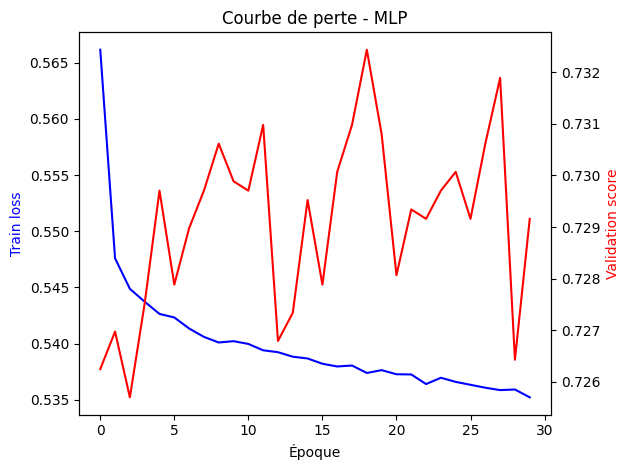

Convergence en 30 époques


In [67]:
# Impact du nombre d'époques : on entraîne sur tout X_app et on trace la courbe de perte
mlp_curve = MLPClassifier(hidden_layer_sizes=(64, 32),
                           activation='relu',
                           learning_rate_init=0.001,
                           max_iter=500,
                           early_stopping=True,
                           validation_fraction=0.1,
                           n_iter_no_change=10,
                           random_state=42)
mlp_curve.fit(X_app, y_app)

# AMÉLIORATION 2 : double axe pour train loss et validation score
fig, ax1 = plt.subplots()
ax1.plot(mlp_curve.loss_curve_, 'b-', label='Train loss')
ax1.set_xlabel("Époque")
ax1.set_ylabel("Train loss", color='b')
if hasattr(mlp_curve, 'validation_scores_'):
    ax2 = ax1.twinx()
    ax2.plot(mlp_curve.validation_scores_, 'r-', label='Validation score')
    ax2.set_ylabel("Validation score", color='r')
plt.title("Courbe de perte - MLP")
fig.tight_layout()
plt.show()
print(f"Convergence en {mlp_curve.n_iter_} époques")

In [68]:
# Impact de la taille du réseau (validation sur X_cv)
architectures = [(32,), (64, 32), (128, 64, 32)]
for arch in architectures:
    m = MLPClassifier(hidden_layer_sizes=arch, activation='relu',
                      max_iter=500, early_stopping=True,
                      validation_fraction=0.1, n_iter_no_change=10,
                      random_state=42)
    scores = cross_validate(m, X_cv, y_cv, cv=cv, scoring=("f1",))
    print(f"Architecture {arch} - F1 moyen : {np.round(np.mean(scores['test_f1']),3)}")

Architecture (32,) - F1 moyen : 0.708
Architecture (64, 32) - F1 moyen : 0.72
Architecture (128, 64, 32) - F1 moyen : 0.717


In [69]:
# Impact du taux d'apprentissage (validation sur X_cv)
learning_rates = [0.0001, 0.001, 0.01]
for lr in learning_rates:
    m = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                      learning_rate_init=lr, max_iter=500,
                      early_stopping=True, validation_fraction=0.1,
                      n_iter_no_change=10, random_state=42)
    scores = cross_validate(m, X_cv, y_cv, cv=cv, scoring=("f1",))
    print(f"Taux d'apprentissage {lr} - F1 moyen : {np.round(np.mean(scores['test_f1']),3)}")

Taux d'apprentissage 0.0001 - F1 moyen : 0.708
Taux d'apprentissage 0.001 - F1 moyen : 0.72
Taux d'apprentissage 0.01 - F1 moyen : 0.719


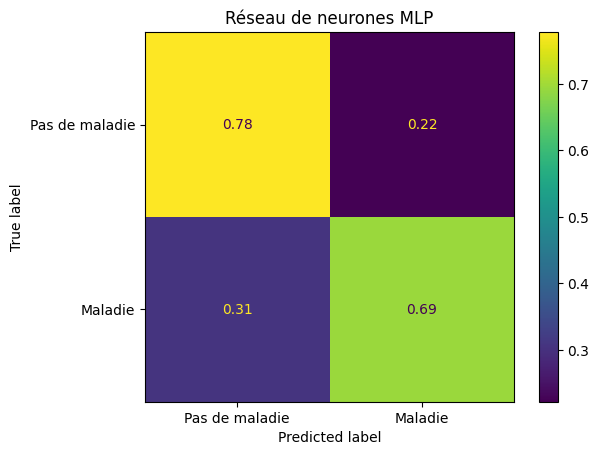

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


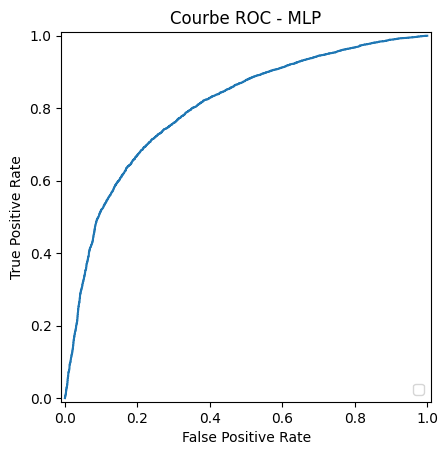

In [70]:
# Entraînement du MLP final sur tout l'ensemble d'apprentissage
mlp.fit(X_app, y_app)
y_pred_mlp = mlp.predict(X_test_np)

cm_mlp = confusion_matrix(y_test_np, y_pred_mlp, normalize='true')
ConfusionMatrixDisplay(cm_mlp, display_labels=["Pas de maladie", "Maladie"]).plot()
plt.title("Réseau de neurones MLP")
plt.show()

y_proba_mlp = mlp.predict_proba(X_test_np)
mlp_fpr, mlp_tpr, _ = roc_curve(y_test_np, y_proba_mlp[:,1])
RocCurveDisplay(fpr=mlp_fpr, tpr=mlp_tpr).plot()
plt.title("Courbe ROC - MLP")
plt.show()

---
# IV : Comparaison des modèles

In [71]:
modeles = {
    "Ridge logistique": (mod_ridge_final, yhat_ridge_test),
    "Lasso logistique": (mod_lasso_final, yhat_lasso_test),
    "KNN"             : (mod_knn_final, yhat_knn_test),
    "Forêt aléatoire" : (rf_best, y_pred_rf),
    "MLP"             : (mlp, y_pred_mlp),
}

print(f"{'Modèle':<22} {'Accuracy':>9} {'Precision':>9} {'Recall':>9} {'F1':>9} {'AUC':>9}")
print("-" * 65)

roc_data = {}
for nom, (mod, y_pred) in modeles.items():
    acc  = accuracy_score(y_test_np, y_pred)
    prec = precision_score(y_test_np, y_pred, zero_division=0)
    rec  = recall_score(y_test_np, y_pred, zero_division=0)
    f1   = f1_score(y_test_np, y_pred, zero_division=0)
    y_proba = mod.predict_proba(X_test_np)[:,1]
    auc  = roc_auc_score(y_test_np, y_proba)
    fpr, tpr, _ = roc_curve(y_test_np, y_proba)
    roc_data[nom] = (fpr, tpr, auc)
    print(f"{nom:<22} {acc:>9.3f} {prec:>9.3f} {rec:>9.3f} {f1:>9.3f} {auc:>9.3f}")

Modèle                  Accuracy Precision    Recall        F1       AUC
-----------------------------------------------------------------
Ridge logistique           0.728     0.756     0.664     0.707     0.794
Lasso logistique           0.728     0.756     0.665     0.708     0.794
KNN                        0.733     0.754     0.684     0.717     0.793
Forêt aléatoire            0.737     0.765     0.675     0.717     0.805
MLP                        0.737     0.754     0.694     0.723     0.802


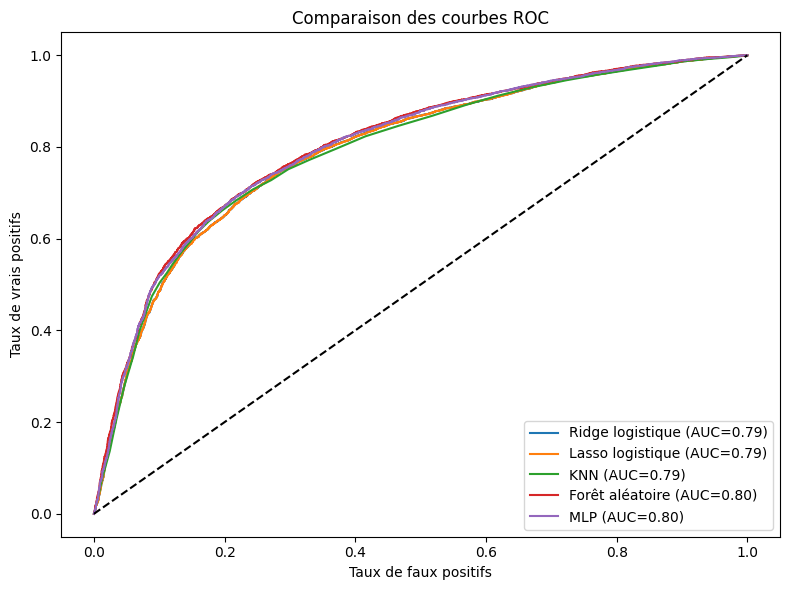

In [72]:
# Courbes ROC comparatives
plt.figure(figsize=(8,6))
for nom, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{nom} (AUC={auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Comparaison des courbes ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

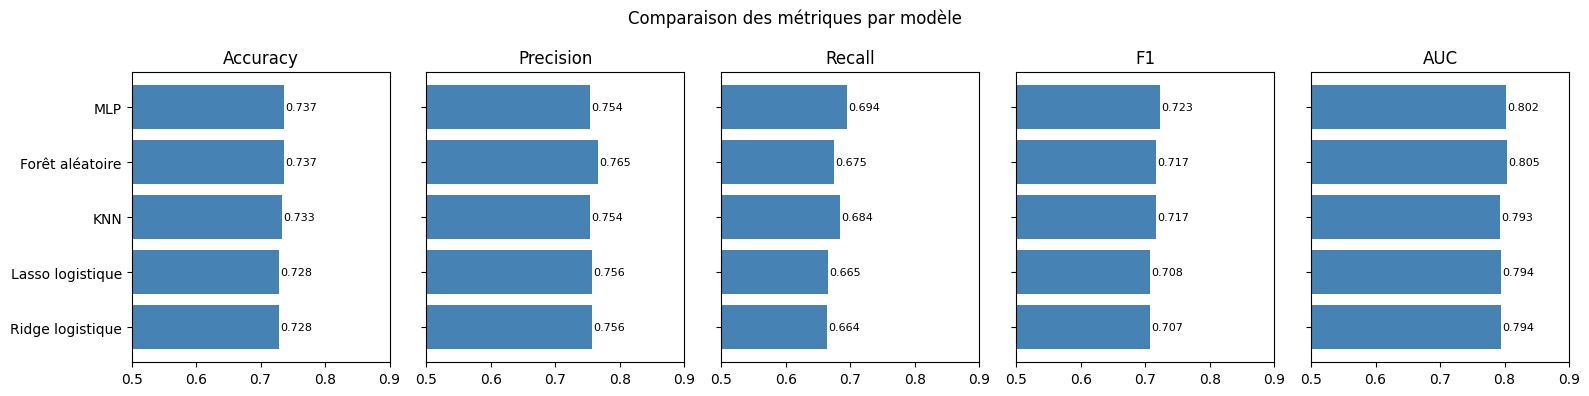

In [73]:
# Comparaison visuelle des métriques entre modèles
noms = list(modeles.keys())
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
values = []
for nom, (mod, y_pred) in modeles.items():
    y_proba = mod.predict_proba(X_test_np)[:,1]
    values.append([
        accuracy_score(y_test_np, y_pred),
        precision_score(y_test_np, y_pred, zero_division=0),
        recall_score(y_test_np, y_pred, zero_division=0),
        f1_score(y_test_np, y_pred, zero_division=0),
        roc_auc_score(y_test_np, y_proba)
    ])

df_metrics = pd.DataFrame(values, index=noms, columns=metrics)

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
for ax, metric in zip(axes, metrics):
    bars = ax.barh(noms, df_metrics[metric], color='steelblue')
    ax.set_title(metric)
    ax.set_xlim(0.5, 0.9)
    for bar, val in zip(bars, df_metrics[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
plt.suptitle('Comparaison des métriques par modèle')
plt.tight_layout()
plt.show()

---
# V : Interprétation et discussion

In [74]:
# Variables les plus importantes selon la forêt aléatoire
importances = rf_best.feature_importances_
indices = np.argsort(importances)[::-1]

print("Variables les plus importantes (Forêt aléatoire) :")
for i in range(len(feature_names)):
    print(f"  {i+1}. {feature_names[indices[i]]:20s} importance = {importances[indices[i]]:.4f}")

Variables les plus importantes (Forêt aléatoire) :
  1. ap_hi                importance = 0.4482
  2. ap_lo                importance = 0.1910
  3. age                  importance = 0.1438
  4. cholesterol          importance = 0.0897
  5. weight               importance = 0.0613
  6. height               importance = 0.0291
  7. gluc                 importance = 0.0146
  8. active               importance = 0.0081
  9. gender               importance = 0.0051
  10. smoke                importance = 0.0049
  11. alco                 importance = 0.0043


In [75]:
# Coefficients Ridge vs Lasso
print("Comparaison des coefficients Ridge et Lasso :\n")
print(f"{'Variable':<20} {'Ridge':>10} {'Lasso':>10}")
print("-" * 42)
for name, cr, cl in zip(feature_names, mod_ridge_final.coef_[0], mod_lasso_final.coef_[0]):
    print(f"{name:<20} {cr:>10.4f} {cl:>10.4f}")

print(f"\nNombre de variables non nulles (Lasso) : {np.sum(mod_lasso_final.coef_[0] != 0)} / {len(mod_lasso_final.coef_[0])}")
print("(Un alpha faible implique une pénalisation faible : peu de variables sont annulées)")

Comparaison des coefficients Ridge et Lasso :

Variable                  Ridge      Lasso
------------------------------------------
age                      0.3408     0.3419
gender                  -0.0453    -0.0431
height                  -0.0293    -0.0291
weight                   0.1598     0.1598
ap_hi                    0.9378     0.9494
ap_lo                    0.0959     0.0897
cholesterol              0.4957     0.5058
gluc                    -0.1258    -0.1336
smoke                   -0.1184    -0.1208
alco                    -0.2027    -0.2184
active                  -0.2104    -0.2185

Nombre de variables non nulles (Lasso) : 11 / 11
(Un alpha faible implique une pénalisation faible : peu de variables sont annulées)
